## 142. 环形链表 II

给定一个链表的头节点  head ，返回链表开始入环的第一个节点。 如果链表无环，则返回 null。

如果链表中有某个节点，可以通过连续跟踪 next 指针再次到达，则链表中存在环。 为了表示给定链表中的环，评测系统内部使用整数 pos 来表示链表尾连接到链表中的位置（索引从 0 开始）。如果 pos 是 -1，则在该链表中没有环。注意：pos 不作为参数进行传递，仅仅是为了标识链表的实际情况。

不允许修改 链表。

![环形链表 II.png](<attachment:环形链表 II.png>)
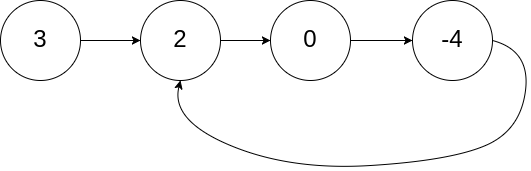

## 快慢指针法

定义快慢两指针，快指针一次走两步，慢指针一次走一步，如果无环，快指针一定先到达 None，如果有环，快慢指针会在环里相遇。

当快慢指针在环内第一次相遇时：

1. 把其中一个指针（比如慢指针）重新放回链表的头节点 head，另一个指针留在相遇点。
2. 让这两个指针以相同的速度（每次各走 1 步）继续前进。

当它们再次相遇时，那个相遇的节点，必定就是环的入口节点！

### 数学证明

定义三个距离变量：

- $a$：从链表头节点到环入口点的距离。
- $b$：从环入口点到快慢指针第一次相遇点的距离。
- $c$：从相遇点继续往前走到环入口点的距离。

环的总长度就是 $b + c$

现在，我们计算两个指针在相遇时走过的路程：

- 慢指针走过的距离：它走了 $a$ 步到达入口，又在环里走了 $b$ 步相遇。所以慢指针走了 $a + b$。
- 快指针走过的距离：它跑得快，在相遇前可能已经在环里转了 $n$ 圈。所以快指针走了 $a + n(b + c) + b$。

因为快指针的速度是慢指针的 2 倍，且时间相同，所以快指针走过的路程必定是慢指针的 2 倍。我们列出等式：

$$2(a + b) = a + n(b + c) + b$$

把这个等式化简，两边同时减去 $(a + b)$：

$$a + b = n(b + c)$$

我们的目标是求出起点到入口的距离 $a$：

$$a = n(b + c) - b$$

为了让这个公式在现实的链表走动中产生意义，我们提取出一个 $(b + c)$，变形为：

$$a = (n - 1)(b + c) + c$$

这个最终等式完美地解释了我们的算法：

左边的 $a$，代表从头节点走到入口的距离。

右边的 $(n - 1)(b + c) + c$，代表从相遇点出发，先在环里转 $(n - 1)$ 圈，最后再走 $c$ 步，也能到达入口。

因此，如果此时指针 A 从头开始走，指针 B 从相遇点开始走。当指针 A 走完 $a$ 步到达入口时，指针 B 刚好在环里转了几圈并走完最后的 $c$ 步，两者必然在环的入口处准时相遇。

### 为什么慢指针走不完一圈？

[text](<142. 环形链表 II.html>)

那么快指针相对于慢指针的速度就是 $2 - 1 = 1$ 步/次。

这就意味着，每走一个回合，快指针就会向慢指针逼近 $1$ 个节点的距离。

假设这个环的总长度是 $L$ 个节点。当慢指针刚入环时，快指针为了从后面追上它，最远需要跑多长的距离？

最倒霉的极端情况是：慢指针刚踏入环，快指针刚刚好就在慢指针的“前面 $1$ 个节点”。这就意味着快指针不能后退，它必须绕环跑几乎完整的一圈，才能从背后抓住慢指针。这个最大追及距离是 $L - 1$。因为快指针每次逼近 $1$ 步，所以快指针最多需要经过 $L - 1$ 个回合，就能追上慢指针。

在这最多 $L - 1$ 个回合中，慢指针每次只走 $1$ 步，因此慢指针最多只会走 $L - 1$ 步。

因为 $L - 1$ 永远严格小于环的总长度 $L$，这就完美地在数学上证明了：在慢指针走完第一圈之前，快指针必定会追上它。

### 代码实现

In [ ]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, x):
#         self.val = x
#         self.next = None

class Solution:
    def detectCycle(self, head: Optional[ListNode]) -> Optional[ListNode]:
        slow = head
        fast = head
        while fast and fast.next:
            slow = slow.next
            fast = fast.next.next
            if fast is slow:
                fast = head
                while fast is not slow:
                    fast = fast.next
                    slow = slow.next
                return fast
        return None